# Prediksi Loan Status — SVR (Without XAI)
Notebook ini melakukan:
1. **Prediksi** Loan_Status menggunakan SVR (threshold 0.5) pada 12 dataset transformasi
2. **Evaluasi** model: Accuracy, Precision, Recall, F1 Score
   - Summary Plot (Bar + Beeswarm)
   - Waterfall Plot (per prediksi)
   - Force Plot (per prediksi)
### Dataset yang digunakan:
| Transformasi | Original | Drop Outliers | Replace Outliers |
|---|---|---|---|
| Z-Score | df_zscore | df_zscore_drop | df_zscore_replace |
| Log | df_log | df_log_drop | df_log_replace |
| MinMax | df_minmax | df_minmax_drop | df_minmax_replace |
| Decimal | df_decimal | df_decimal_drop | df_decimal_replace |


## 1. Install & Import Library


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.svm import SVR, SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score, confusion_matrix, classification_report
)
print('Semua library berhasil diimport!')


Semua library berhasil diimport!


## 2. Import Dataset dari preprocessing2


In [2]:
from preprocessing2 import (
    df_ti_zscore, df_ti_log, df_ti_minmax, df_ti_decimal,
    df_lair_zscore, df_lair_log, df_lair_minmax, df_lair_decimal,
    df_both_zscore, df_both_log, df_both_minmax, df_both_decimal,
    df_ti_zscore_drop, df_ti_log_drop, df_ti_minmax_drop, df_ti_decimal_drop,
    df_lair_zscore_drop, df_lair_log_drop, df_lair_minmax_drop, df_lair_decimal_drop,
    df_both_zscore_drop, df_both_log_drop, df_both_minmax_drop, df_both_decimal_drop,
    df_ti_zscore_replace, df_ti_log_replace, df_ti_minmax_replace, df_ti_decimal_replace,
    df_lair_zscore_replace, df_lair_log_replace, df_lair_minmax_replace, df_lair_decimal_replace,
    df_both_zscore_replace, df_both_log_replace, df_both_minmax_replace, df_both_decimal_replace
)
print('Semua 36 dataset berhasil diimport!')


Semua 36 dataset berhasil diimport!


## 3. Definisi Fungsi SVR + Evaluasi
- Fitur (X) = semua kolom kecuali `Loan_ID` dan `Loan_Status`
- Target (y) = `Loan_Status`
- Split: **80% train / 20% test**
- SVR kernel RBF, prediksi dikonversi ke 0/1 dengan threshold **0.5**


In [3]:
def run_svc(df, dataset_name, test_size=0.2, random_state=42):
    df_clean = df.copy()
    if 'Loan_ID' in df_clean.columns:
        df_clean = df_clean.drop(columns=['Loan_ID'])

    X = df_clean.drop(columns=['Loan_Status'])
    y = df_clean['Loan_Status']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    svr = SVC(kernel='rbf', C=1.0)
    svr.fit(X_train, y_train)

    y_pred_raw = svr.predict(X_test)
    y_pred     = (y_pred_raw >= 0.5).astype(int)

    return {
        'Dataset'   : dataset_name,
        'Accuracy'  : round(accuracy_score(y_test, y_pred), 4),
        'Precision' : round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'    : round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1 Score'  : round(f1_score(y_test, y_pred, zero_division=0), 4),
        'y_test'    : y_test,
        'y_pred'    : y_pred,
        'y_pred_raw': y_pred_raw,
        'cm'        : confusion_matrix(y_test, y_pred),
        'model'     : svr,
        'X_train'   : X_train,
        'X_test'    : X_test,
        'feature_names': X.columns.tolist(),
    }

print('Fungsi SVR siap!')

Fungsi SVR siap!


## 4. Training Semua 12 Model


In [4]:
datasets = {
    'TI ZScore (Original)': df_ti_zscore,
    'TI Log (Original)': df_ti_log,
    'TI MinMax (Original)': df_ti_minmax,
    'TI Decimal (Original)': df_ti_decimal,
    'LAIR ZScore (Original)': df_lair_zscore,
    'LAIR Log (Original)': df_lair_log,
    'LAIR MinMax (Original)': df_lair_minmax,
    'LAIR Decimal (Original)': df_lair_decimal,
    'BOTH ZScore (Original)': df_both_zscore,
    'BOTH Log (Original)': df_both_log,
    'BOTH MinMax (Original)': df_both_minmax,
    'BOTH Decimal (Original)': df_both_decimal,
    'TI ZScore (Drop)': df_ti_zscore_drop,
    'TI Log (Drop)': df_ti_log_drop,
    'TI MinMax (Drop)': df_ti_minmax_drop,
    'TI Decimal (Drop)': df_ti_decimal_drop,
    'LAIR ZScore (Drop)': df_lair_zscore_drop,
    'LAIR Log (Drop)': df_lair_log_drop,
    'LAIR MinMax (Drop)': df_lair_minmax_drop,
    'LAIR Decimal (Drop)': df_lair_decimal_drop,
    'BOTH ZScore (Drop)': df_both_zscore_drop,
    'BOTH Log (Drop)': df_both_log_drop,
    'BOTH MinMax (Drop)': df_both_minmax_drop,
    'BOTH Decimal (Drop)': df_both_decimal_drop,
    'TI ZScore (Replace)': df_ti_zscore_replace,
    'TI Log (Replace)': df_ti_log_replace,
    'TI MinMax (Replace)': df_ti_minmax_replace,
    'TI Decimal (Replace)': df_ti_decimal_replace,
    'LAIR ZScore (Replace)': df_lair_zscore_replace,
    'LAIR Log (Replace)': df_lair_log_replace,
    'LAIR MinMax (Replace)': df_lair_minmax_replace,
    'LAIR Decimal (Replace)': df_lair_decimal_replace,
    'BOTH ZScore (Replace)': df_both_zscore_replace,
    'BOTH Log (Replace)': df_both_log_replace,
    'BOTH MinMax (Replace)': df_both_minmax_replace,
    'BOTH Decimal (Replace)': df_both_decimal_replace,
}

results = {}
for name, data in datasets.items():
    print(f'Training: {name} ...')
    results[name] = run_svc(data, name)

print('\nSemua model selesai ditraining!')


Training: TI ZScore (Original) ...
Training: TI Log (Original) ...
Training: TI MinMax (Original) ...
Training: TI Decimal (Original) ...
Training: LAIR ZScore (Original) ...
Training: LAIR Log (Original) ...
Training: LAIR MinMax (Original) ...
Training: LAIR Decimal (Original) ...
Training: BOTH ZScore (Original) ...
Training: BOTH Log (Original) ...
Training: BOTH MinMax (Original) ...
Training: BOTH Decimal (Original) ...
Training: TI ZScore (Drop) ...
Training: TI Log (Drop) ...
Training: TI MinMax (Drop) ...
Training: TI Decimal (Drop) ...
Training: LAIR ZScore (Drop) ...
Training: LAIR Log (Drop) ...
Training: LAIR MinMax (Drop) ...
Training: LAIR Decimal (Drop) ...
Training: BOTH ZScore (Drop) ...
Training: BOTH Log (Drop) ...
Training: BOTH MinMax (Drop) ...
Training: BOTH Decimal (Drop) ...
Training: TI ZScore (Replace) ...
Training: TI Log (Replace) ...
Training: TI MinMax (Replace) ...
Training: TI Decimal (Replace) ...
Training: LAIR ZScore (Replace) ...
Training: LAIR Log

## 5. Tabel Perbandingan Evaluasi
Hijau = nilai terbaik | Merah = nilai terendah


In [5]:
summary = pd.DataFrame([
    {
        'Dataset'   : r['Dataset'],
        'Accuracy'  : r['Accuracy'],
        'Precision' : r['Precision'],
        'Recall'    : r['Recall'],
        'F1 Score'  : r['F1 Score'],
    }
    for r in results.values()
]).sort_values('F1 Score', ascending=False).reset_index(drop=True)

summary.style.highlight_max(
    subset=['Accuracy','Precision','Recall','F1 Score'], color='lightgreen'
).highlight_min(
    subset=['Accuracy','Precision','Recall','F1 Score'], color='#ffcccc'
)

,Dataset,Accuracy,Precision,Recall,F1 Score
0,LAIR ZScore (Drop),0.872500,0.851900,0.985700,0.913900
1,TI Decimal (Drop),0.862700,0.841500,0.985700,0.907900
2,TI MinMax (Drop),0.862700,0.841500,0.985700,0.907900
3,LAIR MinMax (Drop),0.862700,0.841500,0.985700,0.907900
4,TI ZScore (Drop),0.862700,0.841500,0.985700,0.907900
5,LAIR Decimal (Drop),0.862700,0.841500,0.985700,0.907900
6,BOTH MinMax (Drop),0.862700,0.841500,0.985700,0.907900
7,BOTH Decimal (Drop),0.862700,0.841500,0.985700,0.907900
8,BOTH ZScore (Drop),0.862700,0.850000,0.971400,0.906700
9,BOTH ZScore (Replace),0.853700,0.831700,0.988200,0.903200


## 6. Visualisasi Perbandingan Metrik


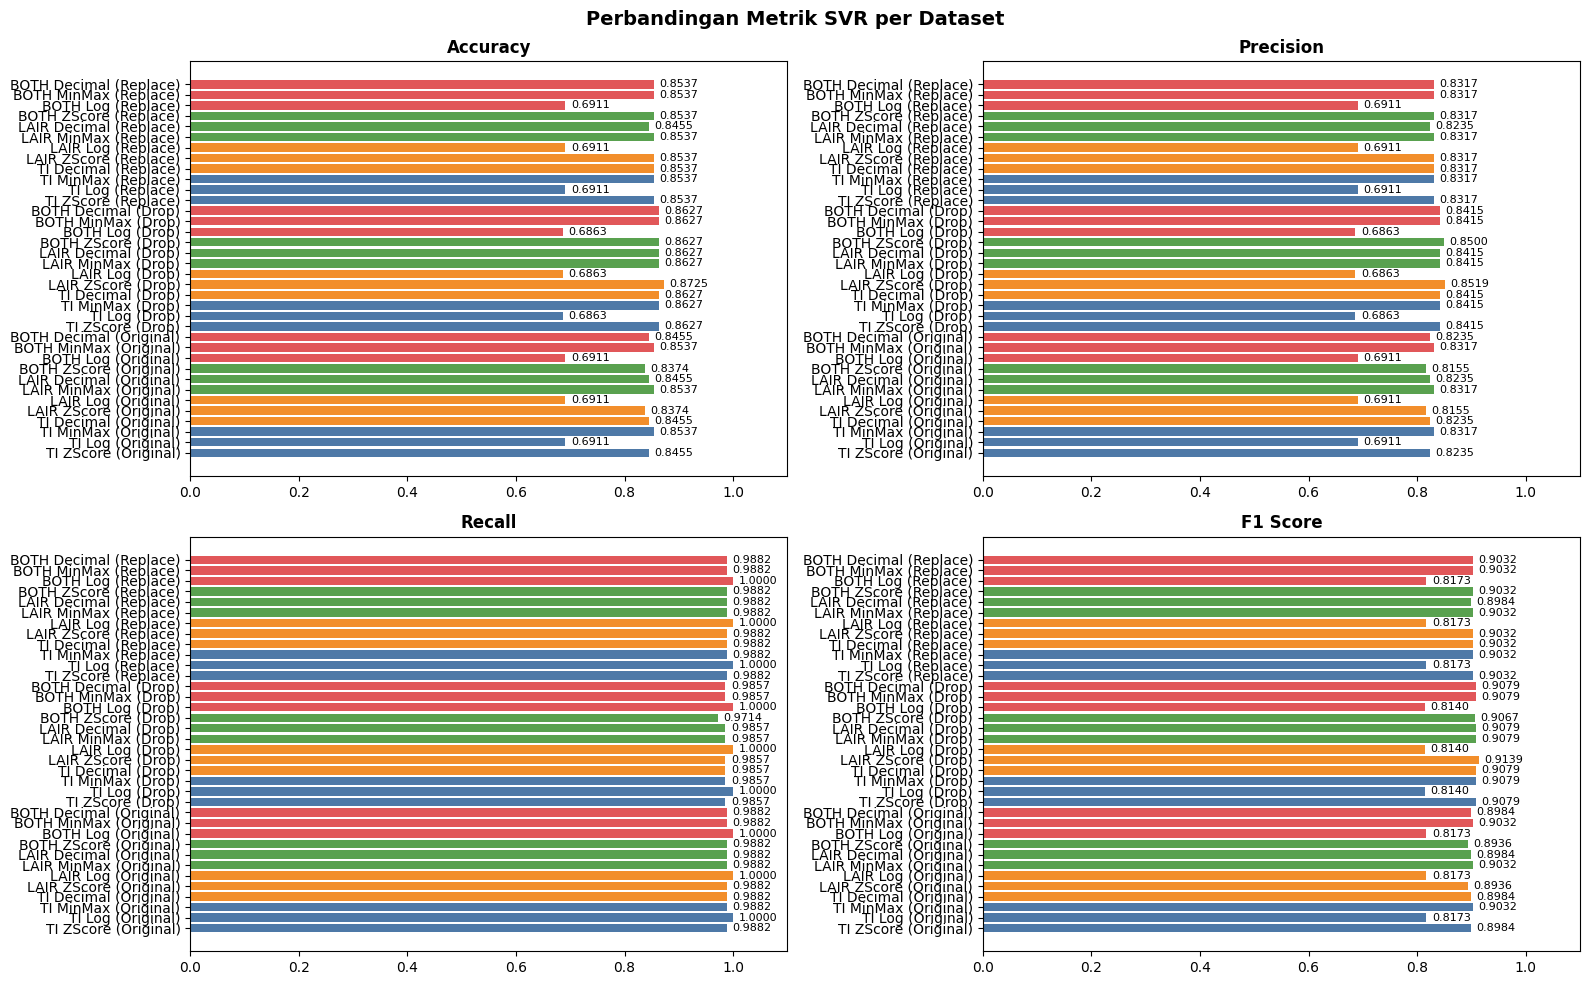

In [6]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors  = ['#4e79a7']*3 + ['#f28e2b']*3 + ['#59a14f']*3 + ['#e15759']*3

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Perbandingan Metrik SVR per Dataset', fontsize=14, fontweight='bold')

for ax, metric in zip(axes.flatten(), metrics):
    vals = [results[n][metric] for n in datasets]
    bars = ax.barh(list(datasets.keys()), vals, color=colors)
    ax.set_xlim(0, 1.1)
    ax.set_title(metric, fontweight='bold')
    for bar, val in zip(bars, vals):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 7. Confusion Matrix Semua Dataset


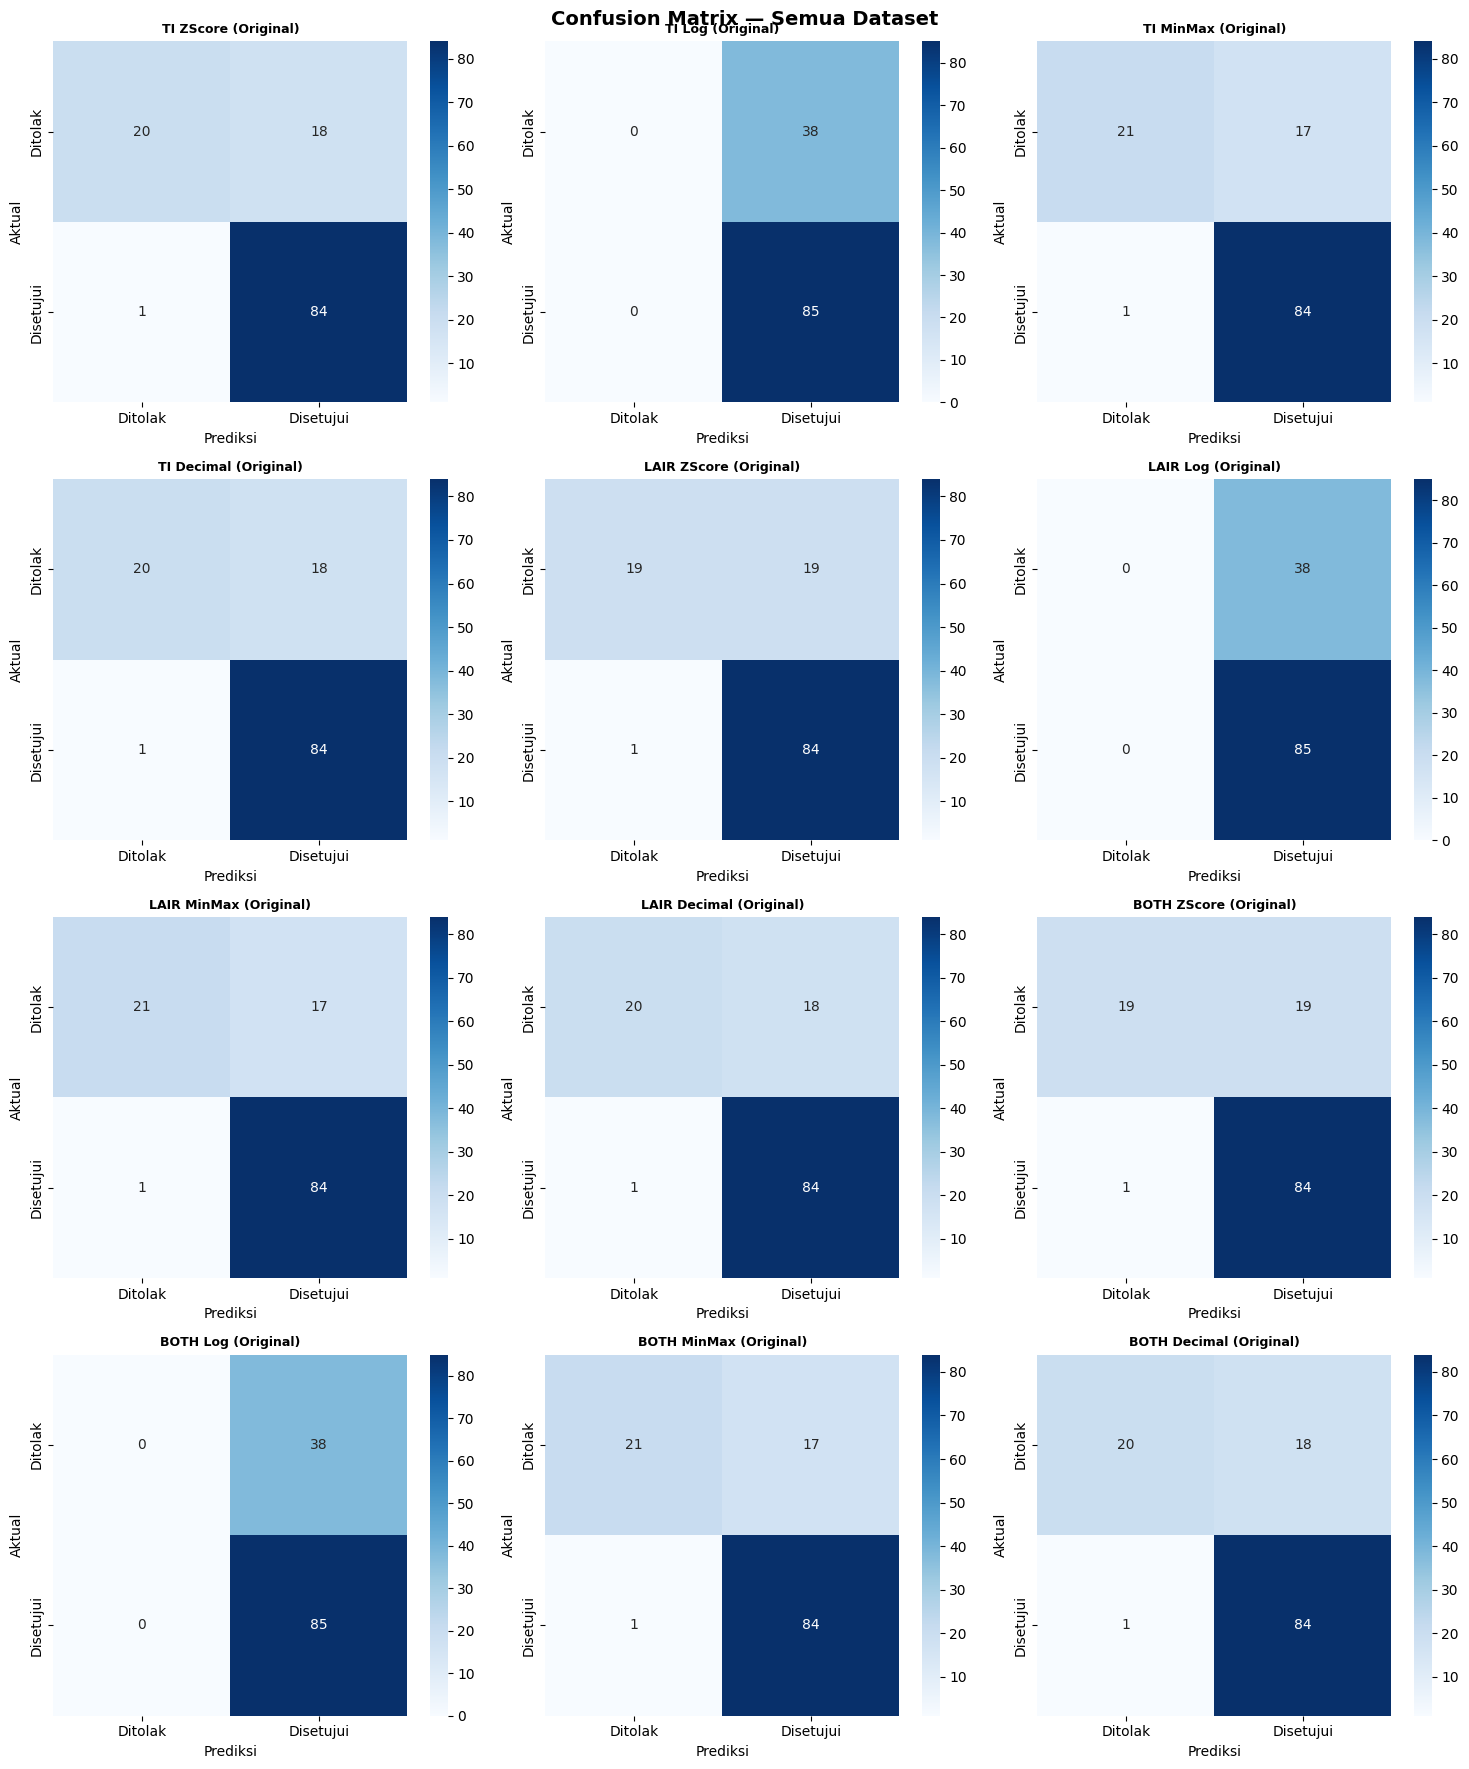

In [7]:
fig, axes = plt.subplots(4, 3, figsize=(15, 18))
fig.suptitle('Confusion Matrix — Semua Dataset', fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes.flatten(), results.items()):
    sns.heatmap(
        res['cm'], annot=True, fmt='d', cmap='Blues',
        xticklabels=['Ditolak','Disetujui'],
        yticklabels=['Ditolak','Disetujui'],
        ax=ax
    )
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_ylabel('Aktual')
    ax.set_xlabel('Prediksi')

plt.tight_layout()
plt.show()

## 8. Classification Report Detail


In [8]:
for name, res in results.items():
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(
        res['y_test'], res['y_pred'],
        target_names=['Ditolak (0)', 'Disetujui (1)'],
        zero_division=0
    ))
    print()

  TI ZScore (Original)
               precision    recall  f1-score   support

  Ditolak (0)       0.95      0.53      0.68        38
Disetujui (1)       0.82      0.99      0.90        85

     accuracy                           0.85       123
    macro avg       0.89      0.76      0.79       123
 weighted avg       0.86      0.85      0.83       123


  TI Log (Original)
               precision    recall  f1-score   support

  Ditolak (0)       0.00      0.00      0.00        38
Disetujui (1)       0.69      1.00      0.82        85

     accuracy                           0.69       123
    macro avg       0.35      0.50      0.41       123
 weighted avg       0.48      0.69      0.56       123


  TI MinMax (Original)
               precision    recall  f1-score   support

  Ditolak (0)       0.95      0.55      0.70        38
Disetujui (1)       0.83      0.99      0.90        85

     accuracy                           0.85       123
    macro avg       0.89      0.77      0.80

## 15. Prediksi Data Baru (Semua Model)
Uji prediksi dengan satu sampel data baru di semua 12 model.


In [9]:
# ── Isi data baru sesuai kebutuhan ─────────────────────────────────
new_data_raw = {
    'Gender'            : 1,
    'Married'           : 1,
    'Dependents'        : 0.0,
    'Education'         : 1,
    'Self_Employed'     : 0,
    'ApplicantIncome'   : 5000,
    'CoapplicantIncome' : 1500,
    'LoanAmount'        : 150,
    'Loan_Amount_Term'  : 360,
    'Credit_History'    : 0.0,
    'Property_Area'     : 1,
    'Total_Income'      : 6500,
    'Loan_Amount_Income_Ratio': (150/6500) + 1,
}
new_df = pd.DataFrame([new_data_raw])
print('Data baru:')
print(new_df.T)


Data baru:
                                    0
Gender                       1.000000
Married                      1.000000
Dependents                   0.000000
Education                    1.000000
Self_Employed                0.000000
ApplicantIncome           5000.000000
CoapplicantIncome         1500.000000
LoanAmount                 150.000000
Loan_Amount_Term           360.000000
Credit_History               0.000000
Property_Area                1.000000
Total_Income              6500.000000
Loan_Amount_Income_Ratio     1.023077


In [10]:
print('HASIL PREDIKSI DATA BARU — SEMUA MODEL')
print('='*60)

new_pred_records = []

for name, res in results.items():
    cols  = res['feature_names']
    model = res['model']

    if not all(c in new_df.columns for c in cols):
        print(f'{name:30s} : Kolom tidak lengkap, skip')
        continue

    pred_raw   = model.predict(new_df[cols])[0]
    pred_label = 1 if pred_raw >= 0.5 else 0
    status     = 'DISETUJUI ✅' if pred_label == 1 else 'DITOLAK ❌'

    print(f'{name:30s} : {status}  (raw={pred_raw:.4f})')
    new_pred_records.append({
        'Dataset' : name,
        'Raw'     : round(pred_raw, 4),
        'Label'   : pred_label,
        'Status'  : 'Disetujui' if pred_label == 1 else 'Ditolak'
    })

pred_df = pd.DataFrame(new_pred_records)
print('='*60)
print(f"Disetujui: {(pred_df['Label']==1).sum()} model | Ditolak: {(pred_df['Label']==0).sum()} model")

HASIL PREDIKSI DATA BARU — SEMUA MODEL
TI ZScore (Original)           : DISETUJUI ✅  (raw=1.0000)
TI Log (Original)              : DISETUJUI ✅  (raw=1.0000)
TI MinMax (Original)           : DISETUJUI ✅  (raw=1.0000)
TI Decimal (Original)          : DISETUJUI ✅  (raw=1.0000)
LAIR ZScore (Original)         : DISETUJUI ✅  (raw=1.0000)
LAIR Log (Original)            : DISETUJUI ✅  (raw=1.0000)
LAIR MinMax (Original)         : DISETUJUI ✅  (raw=1.0000)
LAIR Decimal (Original)        : DISETUJUI ✅  (raw=1.0000)
BOTH ZScore (Original)         : DISETUJUI ✅  (raw=1.0000)
BOTH Log (Original)            : DISETUJUI ✅  (raw=1.0000)
BOTH MinMax (Original)         : DISETUJUI ✅  (raw=1.0000)
BOTH Decimal (Original)        : DISETUJUI ✅  (raw=1.0000)
TI ZScore (Drop)               : DISETUJUI ✅  (raw=1.0000)
TI Log (Drop)                  : DISETUJUI ✅  (raw=1.0000)
TI MinMax (Drop)               : DISETUJUI ✅  (raw=1.0000)
TI Decimal (Drop)              : DISETUJUI ✅  (raw=1.0000)
LAIR ZScore (Drop

## 16. Ringkasan Akhir & Rekomendasi


In [11]:
print('RANGKUMAN PERFORMA MODEL (diurutkan F1 Score)')
print('='*70)
print(summary.to_string(index=False))
best  = summary.iloc[0]
worst = summary.iloc[-1]
print(f'\n🏆 Model TERBAIK   : {best["Dataset"]}')
print(f'   F1={best["F1 Score"]:.4f} | Precision={best["Precision"]:.4f} | Recall={best["Recall"]:.4f} | Accuracy={best["Accuracy"]:.4f}')
print(f'\n⚠️  Model TERENDAH  : {worst["Dataset"]}')
print(f'   F1={worst["F1 Score"]:.4f} | Precision={worst["Precision"]:.4f} | Recall={worst["Recall"]:.4f} | Accuracy={worst["Accuracy"]:.4f}')


RANGKUMAN PERFORMA MODEL (diurutkan F1 Score)
                Dataset  Accuracy  Precision  Recall  F1 Score
     LAIR ZScore (Drop)    0.8725     0.8519  0.9857    0.9139
      TI Decimal (Drop)    0.8627     0.8415  0.9857    0.9079
       TI MinMax (Drop)    0.8627     0.8415  0.9857    0.9079
     LAIR MinMax (Drop)    0.8627     0.8415  0.9857    0.9079
       TI ZScore (Drop)    0.8627     0.8415  0.9857    0.9079
    LAIR Decimal (Drop)    0.8627     0.8415  0.9857    0.9079
     BOTH MinMax (Drop)    0.8627     0.8415  0.9857    0.9079
    BOTH Decimal (Drop)    0.8627     0.8415  0.9857    0.9079
     BOTH ZScore (Drop)    0.8627     0.8500  0.9714    0.9067
  BOTH ZScore (Replace)    0.8537     0.8317  0.9882    0.9032
  BOTH MinMax (Replace)    0.8537     0.8317  0.9882    0.9032
   TI MinMax (Original)    0.8537     0.8317  0.9882    0.9032
 BOTH Decimal (Replace)    0.8537     0.8317  0.9882    0.9032
  LAIR ZScore (Replace)    0.8537     0.8317  0.9882    0.9032
    TI Mi